Title - BigMart Sales Prediction Model Using XGBoost Regressor
Goal - Predict 'Item_Outlet_Sales' (Target Variable) using the model

1. Import Necessary Libraries

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import joblib


warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Create output folders
for folder in ["models", "outputs"]:
    os.makedirs(folder, exist_ok=True)
print("Libraries imported successfully.")

Libraries imported successfully.


2. Load the date into Datasets

In [2]:
train = pd.read_csv("data/Train.csv")
test = pd.read_csv("data/Test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape : {test.shape}")


Train shape: (8523, 12)
Test shape : (5681, 11)


3. Inspect the data

In [3]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
train.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [6]:
train.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [7]:
train.describe(include="object")

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,8523,8523,8523,8523,6113,8523,8523
unique,1559,5,16,10,3,3,4
top,FDW13,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,10,5089,1232,935,2793,3350,5577


In [9]:
# Unique value counts for every categorical column — surfaces inconsistent labels

categorical_col = train.select_dtypes(include='object').columns.tolist()
categorical_col = [c for c in categorical_col if c not in ['Item_Identifier', 'source']]

for col in categorical_col:
    print(f"\n--- {col} ({train[col].nunique()} unique values) ---")
    print(train[col].value_counts(dropna=False))


--- Item_Fat_Content (5 unique values) ---
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

--- Item_Type (16 unique values) ---
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

--- Outlet_Identifier (10 unique values) ---
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dtype: int64

--- Outlet_Size (3 unique values) ---
Outlet_Siz

4. Exploratory Data Analysis

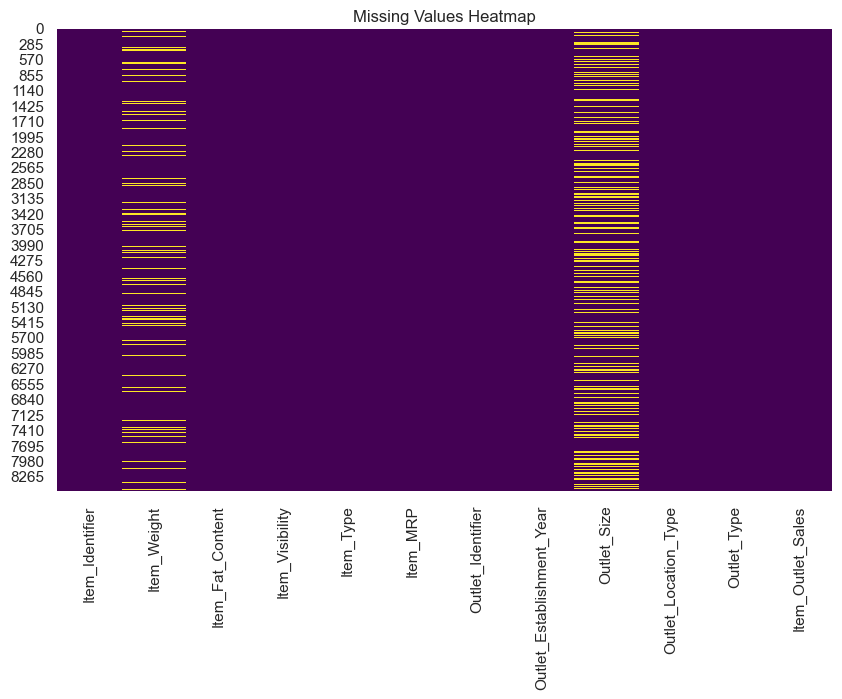

In [10]:
#Missing value heatmap

plt.figure(figsize=(10, 6))
sns.heatmap(train.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

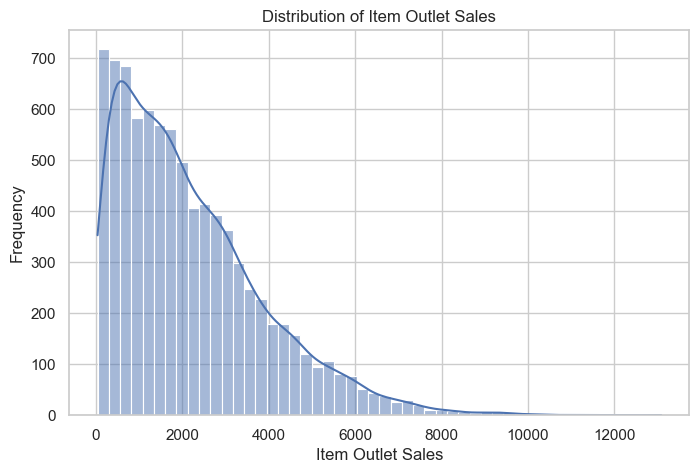

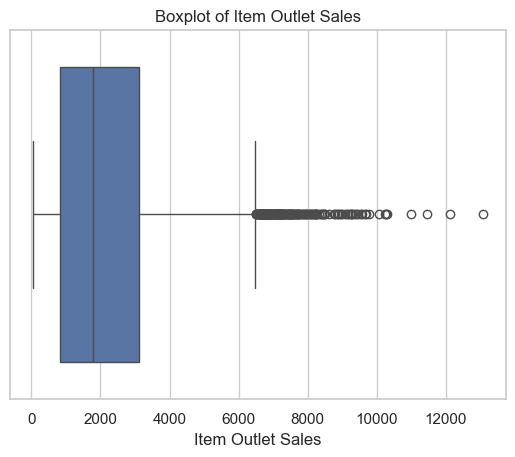

In [12]:
#Distribution of target variable

plt.figure(figsize=(8, 5))
sns.histplot(train["Item_Outlet_Sales"], bins=50, kde=True)
plt.title("Distribution of Item Outlet Sales")
plt.xlabel("Item Outlet Sales")
plt.ylabel("Frequency")
plt.show()

sns.boxplot(x=train["Item_Outlet_Sales"])
plt.title("Boxplot of Item Outlet Sales")
plt.xlabel("Item Outlet Sales")
plt.show()

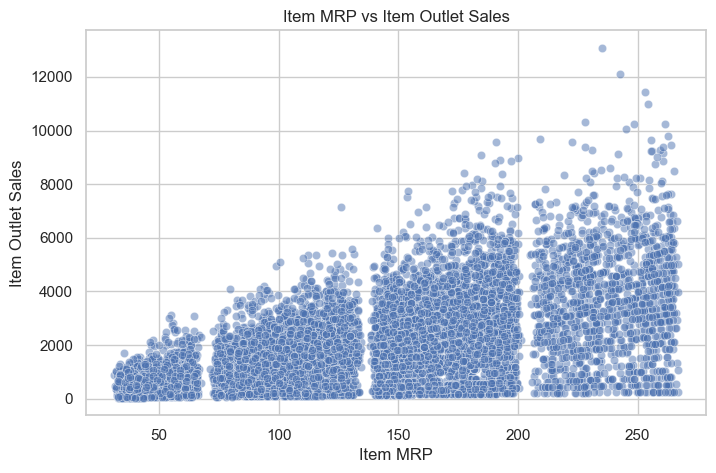

In [13]:
#Item mrp vs sales

plt.figure(figsize=(8, 5))
sns.scatterplot(x=train["Item_MRP"], y=train["Item_Outlet_Sales"], alpha=0.5)
plt.title("Item MRP vs Item Outlet Sales")
plt.xlabel("Item MRP")
plt.ylabel("Item Outlet Sales")
plt.show()

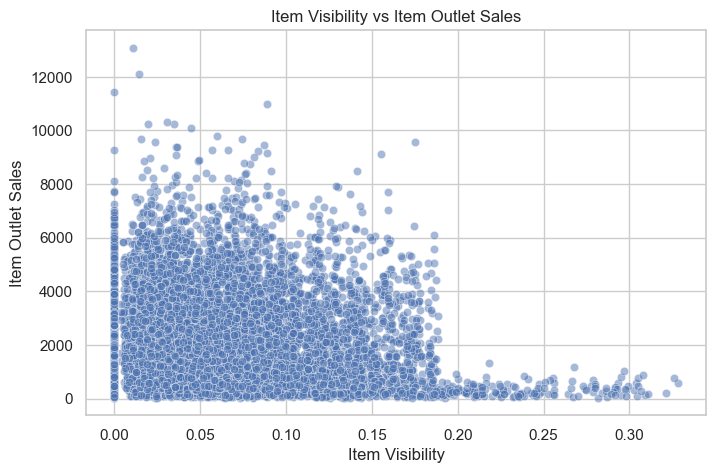

In [14]:
#Item visibility vs sales

plt.figure(figsize=(8, 5))
sns.scatterplot(x=train["Item_Visibility"], y=train["Item_Outlet_Sales"], alpha=0.5)
plt.title("Item Visibility vs Item Outlet Sales")
plt.xlabel("Item Visibility")
plt.ylabel("Item Outlet Sales")
plt.show()

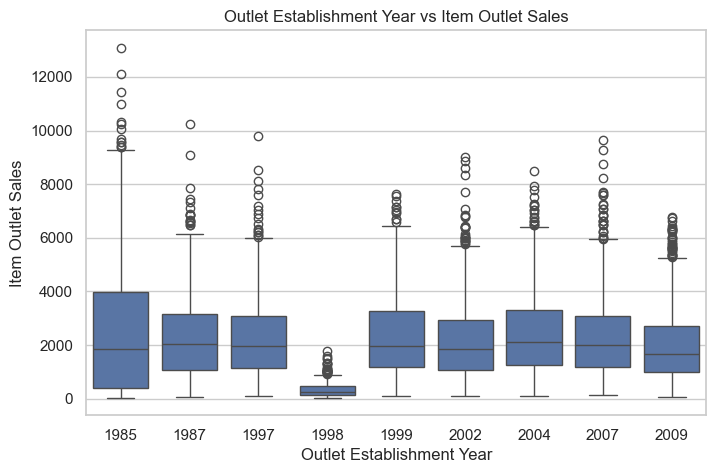

In [15]:
#Outlet establishment year vs sales

plt.figure(figsize=(8, 5))
sns.boxplot(x=train["Outlet_Establishment_Year"], y=train["Item_Outlet_Sales"])
plt.title("Outlet Establishment Year vs Item Outlet Sales")
plt.xlabel("Outlet Establishment Year")
plt.ylabel("Item Outlet Sales")
plt.show()

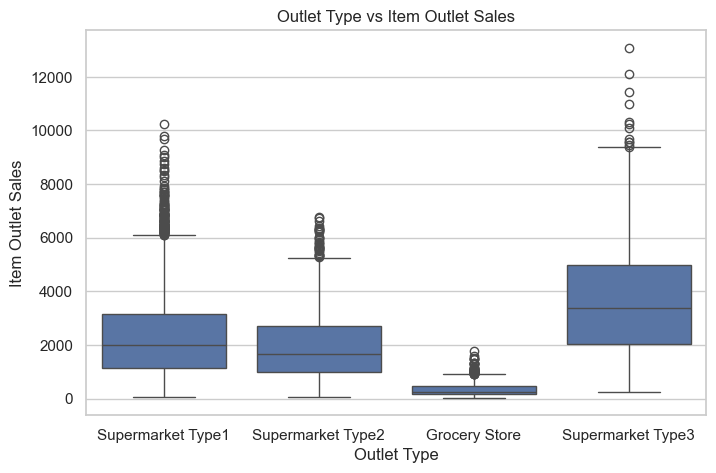

In [17]:
#Sales distribution across outlet types

plt.figure(figsize=(8, 5))
sns.boxplot(x=train["Outlet_Type"], y=train["Item_Outlet_Sales"])
plt.title("Outlet Type vs Item Outlet Sales")
plt.xlabel("Outlet Type")
plt.ylabel("Item Outlet Sales")
plt.show()

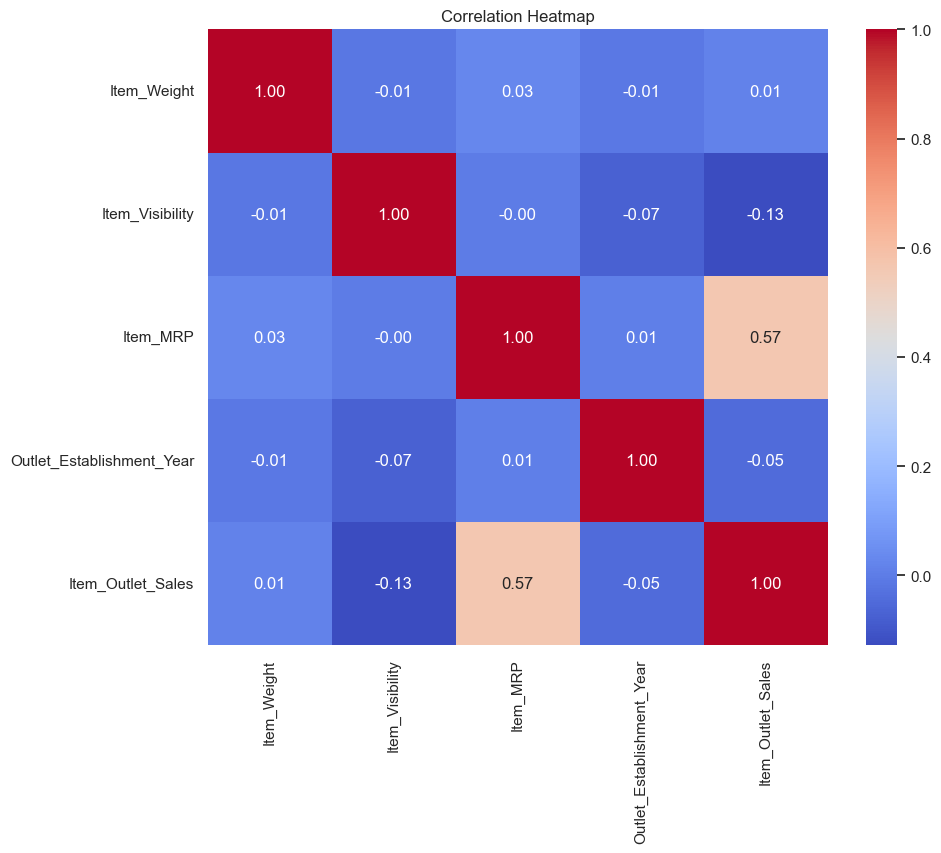

In [16]:
#Correlation heatmap for numerical features

numerical_cols = train.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove("Item_Outlet_Sales")  # Exclude target variable

plt.figure(figsize=(10, 8))
sns.heatmap(train[numerical_cols + ["Item_Outlet_Sales"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

5. Data Cleaning

In [20]:
train['source'] = 'train'
test['source'] = 'test'

data = pd.concat([train, test], ignore_index=True, sort=False)
print(f"Combined shape: {data.shape}")
data.columns = data.columns.str.strip()
print(f"Train rows: {(data['source'] == 'train').sum()}, Test rows: {(data['source'] == 'test').sum()}")

Combined shape: (14204, 13)
Train rows: 8523, Test rows: 5681


In [ ]:
#Duplicate rows

duplicate_rows = data.drop(columns=['source']).duplicated().sum()
duplicate_items = data['Item_Identifier'].duplicated().sum()
print(f"Fully duplicated rows: {duplicate_rows}")
print(f"Duplicated Item Identifiers: {duplicate_items}")



Fully duplicated rows: 0
Duplicated Item Identifiers: 12645


In [23]:
#Standardize Features - Item_Fat_Content has inconsistent labels for the same category. We will standardize them.

print("Before cleaning:")
print(data['Item_Fat_Content'].value_counts())

data['Item_Fat_Content'] = data['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

print("\nAfter cleaning:")
print(data['Item_Fat_Content'].value_counts())


Before cleaning:
Item_Fat_Content
Low Fat    8485
Regular    4824
LF          522
reg         195
low fat     178
Name: count, dtype: int64

After cleaning:
Item_Fat_Content
Low Fat    9185
Regular    5019
Name: count, dtype: int64


In [24]:
#Imputation of Item_Weight

weight_consistency = data.groupby('Item_Identifier')['Item_Weight'].nunique()
inconsistent_items = (weight_consistency > 1).sum()
print(f"Items with more than one distinct recorded weight: {inconsistent_items} out of {len(weight_consistency)}")
print("Confirms Item_Weight is a fixed product attribute -> safe to impute via per-item lookup.\n")

missing_before = data['Item_Weight'].isnull().sum()

item_weight_map = data.dropna(subset=['Item_Weight']).groupby('Item_Identifier')['Item_Weight'].mean()
data['Item_Weight'] = data.apply(
    lambda row: item_weight_map.get(row['Item_Identifier'], np.nan)
    if pd.isnull(row['Item_Weight']) else row['Item_Weight'],
    axis=1
)

# Fallback for any item with zero non-null observations anywhere: overall mean
remaining_missing = data['Item_Weight'].isnull().sum()
if remaining_missing > 0:
    data['Item_Weight'] = data['Item_Weight'].fillna(data['Item_Weight'].mean())

print(f"Item_Weight missing before: {missing_before}")
print(f"Item_Weight missing after per-item lookup: {remaining_missing}")
print(f"Item_Weight missing after fallback: {data['Item_Weight'].isnull().sum()}")


Items with more than one distinct recorded weight: 0 out of 1559
Confirms Item_Weight is a fixed product attribute -> safe to impute via per-item lookup.

Item_Weight missing before: 2439
Item_Weight missing after per-item lookup: 0
Item_Weight missing after fallback: 0


In [25]:
#Imputation of Outlet_Size

missing_size_outlets = data[data['Outlet_Size'].isnull()]['Outlet_Identifier'].unique()
print(f"Outlets with missing Outlet_Size: {list(missing_size_outlets)}")
print("\nMode Outlet_Size by Outlet_Type (computed from non-missing rows):")
outlet_size_mode = data.dropna(subset=['Outlet_Size']).groupby('Outlet_Type')['Outlet_Size'].agg(lambda x: x.mode().iloc[0])
print(outlet_size_mode)

missing_before_size = data['Outlet_Size'].isnull().sum()
data['Outlet_Size'] = data.apply(
    lambda row: outlet_size_mode.get(row['Outlet_Type'], 'Small') if pd.isnull(row['Outlet_Size']) else row['Outlet_Size'],
    axis=1
)
print(f"\nOutlet_Size missing before: {missing_before_size}, after: {data['Outlet_Size'].isnull().sum()}")

Outlets with missing Outlet_Size: ['OUT010', 'OUT045', 'OUT017']

Mode Outlet_Size by Outlet_Type (computed from non-missing rows):
Outlet_Type
Grocery Store         Small
Supermarket Type1     Small
Supermarket Type2    Medium
Supermarket Type3    Medium
Name: Outlet_Size, dtype: object

Outlet_Size missing before: 4016, after: 0


In [ ]:
#Imputation of Item_Outlet_Sales

missing_sales = data['Item_Outlet_Sales'].isnull().sum()
print(f"Missing Item_Outlet_Sales in combined data: {missing_sales}")

In [ ]:
#Final check for any remaining missing values

print("\nRemaining missing values per column:")
print(data.isnull().sum())

#Note that all missing values are now in the target variable, which is expected since the test set has no sales data.
#The training set has no missing values, so we can proceed with modeling without needing to impute the target.


Remaining missing values per column:
Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales            5681
source                          0
dtype: int64


6. Feature Engineering

In [29]:
#Outlet Age

REFERENCE_YEAR = 2013  # dataset reference year (most recent establishment year is 2009)
data['Outlet_Age'] = REFERENCE_YEAR - data['Outlet_Establishment_Year']
print(data[['Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Age']].drop_duplicates().sort_values('Outlet_Age'))

   Outlet_Identifier  Outlet_Establishment_Year  Outlet_Age
1             OUT018                       2009           4
9             OUT017                       2007           6
19            OUT035                       2004           9
8             OUT045                       2002          11
0             OUT049                       1999          14
3             OUT010                       1998          15
11            OUT046                       1997          16
4             OUT013                       1987          26
7             OUT027                       1985          28
23            OUT019                       1985          28


In [30]:
#Item Category

data['Item_Category'] = data['Item_Identifier'].str[:2].map({
    'FD': 'Food', 'DR': 'Drinks', 'NC': 'Non-Consumable'
})
print(data['Item_Category'].value_counts())
print("\nCross-check against Item_Type (first few categories per prefix):")
print(data.groupby('Item_Category')['Item_Type'].unique())

Item_Category
Food              10201
Non-Consumable     2686
Drinks             1317
Name: count, dtype: int64

Cross-check against Item_Type (first few categories per prefix):
Item_Category
Drinks                            [Soft Drinks, Hard Drinks, Dairy]
Food              [Dairy, Meat, Fruits and Vegetables, Baking Go...
Non-Consumable              [Household, Health and Hygiene, Others]
Name: Item_Type, dtype: object


In [31]:
#Item_Fat_Content

print("Item_Fat_Content distribution within Non-Consumable category (before fix):")
print(data.loc[data['Item_Category'] == 'Non-Consumable', 'Item_Fat_Content'].value_counts())

data.loc[data['Item_Category'] == 'Non-Consumable', 'Item_Fat_Content'] = 'Non-Edible'

print("\nItem_Fat_Content distribution overall (after fix):")
print(data['Item_Fat_Content'].value_counts())


Item_Fat_Content distribution within Non-Consumable category (before fix):
Item_Fat_Content
Low Fat    2686
Name: count, dtype: int64

Item_Fat_Content distribution overall (after fix):
Item_Fat_Content
Low Fat       6499
Regular       5019
Non-Edible    2686
Name: count, dtype: int64


In [32]:
#Fix Item_Visibility = 0 values

zero_count = (data['Item_Visibility'] == 0).sum()
print(f"Item_Visibility == 0 rows: {zero_count}")

data['Item_Visibility'] = data['Item_Visibility'].replace(0, np.nan)
visibility_mean_by_type = data.groupby('Item_Type')['Item_Visibility'].transform('mean')
data['Item_Visibility'] = data['Item_Visibility'].fillna(visibility_mean_by_type)

print(f"Item_Visibility == 0 rows after fix: {(data['Item_Visibility'] == 0).sum()}")

Item_Visibility == 0 rows: 0
Item_Visibility == 0 rows after fix: 0


In [33]:
#Item Visibility Mean Ratio

mean_vis_per_item = data.groupby('Item_Identifier')['Item_Visibility'].transform('mean')
data['Item_Visibility_MeanRatio'] = data['Item_Visibility'] / mean_vis_per_item
print(data[['Item_Identifier', 'Item_Visibility', 'Item_Visibility_MeanRatio']].head())


  Item_Identifier  Item_Visibility  Item_Visibility_MeanRatio
0           FDA15        -0.969852                   1.024383
1           DRC01        -0.907063                   1.030356
2           FDN15        -0.956000                   1.014374
3           FDX07        -1.281712                   1.370634
4           NCD19        -1.281712                   1.174102


In [34]:
#Item_MRP_Per_Weight

data['Item_MRP_Per_Weight'] = data['Item_MRP'] / data['Item_Weight']
print(data[['Item_MRP', 'Item_Weight', 'Item_MRP_Per_Weight']].head())

   Item_MRP  Item_Weight  Item_MRP_Per_Weight
0  1.752511    -0.750779            -2.334256
1 -1.493696    -1.477301             1.011098
2  0.009874     1.011788             0.009759
3  0.661838     1.377198             0.480568
4 -1.403623    -0.830310             1.690481


Item_MRP_Bin
Low          3552
Medium       3552
High         3551
Very High    3549
Name: count, dtype: int64


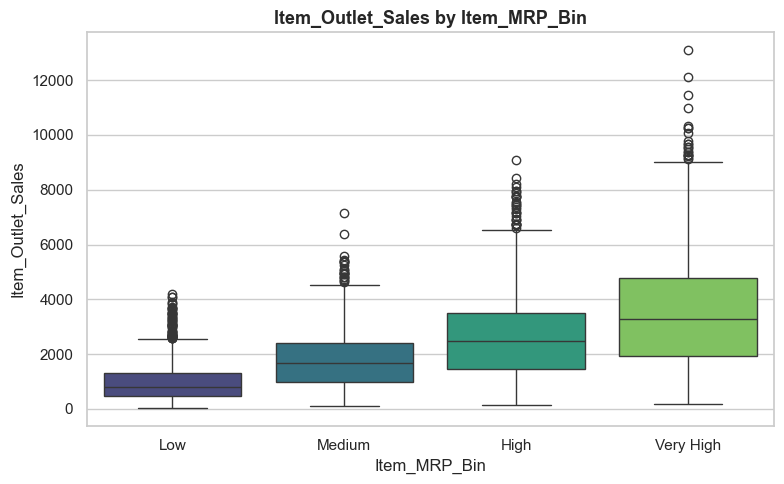

In [35]:
#Item_MRP_Bin

data['Item_MRP_Bin'] = pd.qcut(data['Item_MRP'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
print(data['Item_MRP_Bin'].value_counts())

plt.figure(figsize=(8, 5))
sns.boxplot(data=data[data['source'] == 'train'], x='Item_MRP_Bin', y='Item_Outlet_Sales',
            order=['Low', 'Medium', 'High', 'Very High'], palette='viridis')
plt.title('Item_Outlet_Sales by Item_MRP_Bin', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
